In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sonar.all-data",header=None)
df.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
117,0.0228,0.0106,0.0130,0.0842,0.1117,0.1506,0.1776,0.0997,0.1428,0.2227,...,0.0098,0.0178,0.0077,0.0074,0.0095,0.0055,0.0045,0.0063,0.0039,M
178,0.0197,0.0394,0.0384,0.0076,0.0251,0.0629,0.0747,0.0578,0.1357,0.1695,...,0.0134,0.0097,0.0042,0.0058,0.0072,0.0041,0.0045,0.0047,0.0054,M
45,0.0408,0.0653,0.0397,0.0604,0.0496,0.1817,0.1178,0.1024,0.0583,0.2176,...,0.0062,0.0129,0.0184,0.0069,0.0198,0.0199,0.0102,0.0070,0.0055,R
106,0.0331,0.0423,0.0474,0.0818,0.0835,0.0756,0.0374,0.0961,0.0548,0.0193,...,0.0078,0.0174,0.0176,0.0038,0.0129,0.0066,0.0044,0.0134,0.0092,M
58,0.0225,0.0019,0.0075,0.0097,0.0445,0.0906,0.0889,0.0655,0.1624,0.1452,...,0.0034,0.0129,0.0100,0.0044,0.0057,0.0030,0.0035,0.0021,0.0027,R


In [3]:
len(df.columns)

61

In [4]:
df[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

In [5]:
df[60] = df[60].map({"R":1,"M":0})

In [6]:
X = df.drop(60,axis=1)
y = df[60]

In [7]:
type(y)

pandas.core.series.Series

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=1)

In [9]:
type(X_train.values)

numpy.ndarray

In [10]:
X_train_tensor = torch.tensor(X_train.values,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.long)

In [11]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [12]:
train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=False)

### Simple Neural Network

In [13]:
for a,b in train_loader:
    print (a,b)
    break

tensor([[0.0164, 0.0173, 0.0347, 0.0070, 0.0187, 0.0671, 0.1056, 0.0697, 0.0962,
         0.0251, 0.0801, 0.1056, 0.1266, 0.0890, 0.0198, 0.1133, 0.2826, 0.3234,
         0.3238, 0.4333, 0.6068, 0.7652, 0.9203, 0.9719, 0.9207, 0.7545, 0.8289,
         0.8907, 0.7309, 0.6896, 0.5829, 0.4935, 0.3101, 0.0306, 0.0244, 0.1108,
         0.1594, 0.1371, 0.0696, 0.0452, 0.0620, 0.1421, 0.1597, 0.1384, 0.0372,
         0.0688, 0.0867, 0.0513, 0.0092, 0.0198, 0.0118, 0.0090, 0.0223, 0.0179,
         0.0084, 0.0068, 0.0032, 0.0035, 0.0056, 0.0040],
        [0.0072, 0.0027, 0.0089, 0.0061, 0.0420, 0.0865, 0.1182, 0.0999, 0.1976,
         0.2318, 0.2472, 0.2880, 0.2126, 0.0708, 0.1194, 0.2808, 0.4221, 0.5279,
         0.5857, 0.6153, 0.6753, 0.7873, 0.8974, 0.9828, 1.0000, 0.8460, 0.6055,
         0.3036, 0.0144, 0.2526, 0.4335, 0.4918, 0.5409, 0.5961, 0.5248, 0.3777,
         0.2369, 0.1720, 0.1878, 0.3250, 0.2575, 0.2423, 0.2706, 0.2323, 0.1724,
         0.1457, 0.1175, 0.0868, 0.0392, 0.0131, 0.

In [14]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(60,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,2)
        )
    def forward(self,x):
        return self.network(x)

#### Model Training

In [15]:
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [16]:
model.train()
epochs = 20
train_losses,val_losses,val_accuracies = [],[],[]
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for inputs,labels in train_loader:
        optimizer.zero_grad()
        predictions = model(inputs)
        loss = criterion(predictions,labels)
        epoch_loss += loss.item()
        loss.backward()
        optimizer.step()
    avg_batch_loss = epoch_loss/len(train_loader)
    train_losses.append(avg_batch_loss)

    model.eval()
    with torch.no_grad():
        running_val_loss = 0.0
        true_lables,all_pred = [],[]
        for inputs,labels in test_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs,labels)
            running_val_loss += val_loss.item()
            _,pred = torch.max(outputs,1)
            true_lables.extend(labels.cpu().numpy())
            all_pred.extend(pred.cpu().numpy())
        val_losses.append(running_val_loss/len(test_loader))
        val_accuracy = accuracy_score(true_lables,all_pred)
        val_accuracies.append(val_accuracy)
    print(f"Epoch: {epoch+1}/{epochs}, Training_Loss: { train_losses[-1]: .4f}, val_loss: {val_losses[-1] :.4f}, val_accuracy: {val_accuracies[-1]:.4f}")

Epoch: 1/20, Training_Loss:  0.6901, val_loss: 0.6669, val_accuracy: 0.5192
Epoch: 2/20, Training_Loss:  0.6759, val_loss: 0.6620, val_accuracy: 0.5192
Epoch: 3/20, Training_Loss:  0.6625, val_loss: 0.6449, val_accuracy: 0.6346
Epoch: 4/20, Training_Loss:  0.6402, val_loss: 0.6224, val_accuracy: 0.6731
Epoch: 5/20, Training_Loss:  0.6122, val_loss: 0.5847, val_accuracy: 0.7308
Epoch: 6/20, Training_Loss:  0.5770, val_loss: 0.5713, val_accuracy: 0.7885
Epoch: 7/20, Training_Loss:  0.5662, val_loss: 0.5324, val_accuracy: 0.6731
Epoch: 8/20, Training_Loss:  0.5251, val_loss: 0.5554, val_accuracy: 0.7500
Epoch: 9/20, Training_Loss:  0.4872, val_loss: 0.5050, val_accuracy: 0.7500
Epoch: 10/20, Training_Loss:  0.4536, val_loss: 0.5446, val_accuracy: 0.7500
Epoch: 11/20, Training_Loss:  0.4388, val_loss: 0.5057, val_accuracy: 0.7692
Epoch: 12/20, Training_Loss:  0.4069, val_loss: 0.4924, val_accuracy: 0.7308
Epoch: 13/20, Training_Loss:  0.4045, val_loss: 0.4871, val_accuracy: 0.7500
Epoch: 1

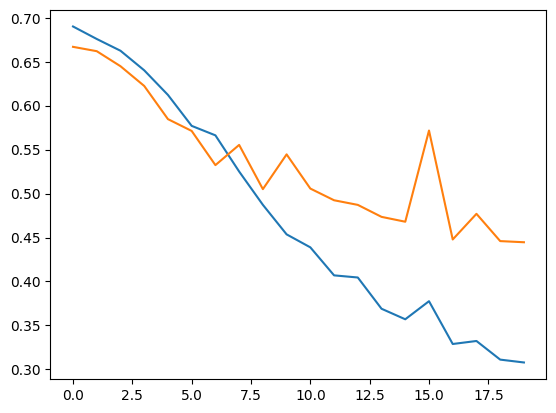

In [17]:
plt.plot(train_losses)
plt.plot(val_losses)